### Predicting Wind Turbine Power Output: Regression Analysis
Lisa Wei
0614940
12/01/2026


AI disclaimer:
Ik heb LLM's gebruikt namelijk Gemini 3 vooral voor het genereren van code en debuggen, maar ook om concepten te begrijpen en het helpen bij het structureren van de opbouw van dit rapport. Ik zal vermelden wanneer er iets AI gegenereerd is. Alle teksten gegenereerd m.b.v. AI staat tussen aanhalingstekens " ". Ik heb soms zelf aanpassingen gedaan in die teksten.


In [1]:
# numerical library:
import numpy as np

# data manipulation library:
import pandas as pd

# standard packages used to handle files:
import sys
import os 
import glob
import time

# scikit-learn machine learning library:
import sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error

# plotting:
import matplotlib.pyplot as plt
import seaborn as sns

# tell matplotlib that we plot in a notebook:
%matplotlib inline

Sinds mijn intermediate report ben ik opnieuw begonnen, want eigenlijk begreep ik niets van wat ik deed. 

Ik ben nu begonnen met alle bruikbare code over te nemen van de start_here en example_classification file. Daarna heb ik mijn eerste lineaire regressie model getraind. 

## Problem and data analysis

In dit geval hebben we een supervised regressieprobleem. Het is supervised omdat we een gelabelde dataset krijgen, dus voor elke feature (wind speed, temperatuur...) hebben we een target value (active_power). Het is een regressieprobleem omdat onze target value (active_power) een continue waarde is, en dus geen discrete klasse.

We proberen voor ons model de MAE te minimaliseren.

AI gegenereerde hypothese:
"I expect a non-linear relationship between wind speed and power. While Linear Regression will serve as a baseline, I hypothesize that Gradient Boosted Trees (like XGBoost or LightGBM) will perform better due to their ability to capture the 'cut-in' (snelheid waarbij de turbine begint te draaien) and 'rated power' (maximale capaciteit van de turbine) plateaus without manual feature transformations."

In [2]:
data_folder = "./"

In [3]:
train_data = pd.read_csv(data_folder + "training_data.csv")
test_data = pd.read_csv(data_folder + "test_data.csv")

In [4]:
train_data.head()

,active_power,timestamp,pitch_angle,reactive_power,nacelle_angle,nacelle_temp,wind_speed1,wind_speed2,wind_speed_avg,wind_angle,...,outdoor_temp,rotor_angular_velocity,rotor_bearing_temp,weather_temp,pressure,humidity,weather_wind_speed,weather_wind_angle,rain_1h,snow_1h
0,801.22998,2013-01-01 00:00:00,-1.0,67.559998,286.00000,20.129999,7.52,7.76,7.64,286.19000,...,5.44,16.950001,26.049999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
1,943.16998,2013-01-01 00:10:00,-1.0,70.260002,286.00000,21.420000,8.18,8.45,8.31,288.32999,...,5.74,17.139999,26.100000,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
2,998.48999,2013-01-01 00:20:00,-1.0,75.330002,286.00000,22.049999,8.29,8.66,8.47,293.04001,...,6.09,17.150000,26.219999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
3,837.96002,2013-01-01 00:30:00,-1.0,82.739998,286.00000,22.299999,7.89,8.24,8.06,294.01999,...,6.35,16.910000,26.309999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
4,871.57001,2013-01-01 00:40:00,-1.0,82.349998,294.17999,22.600000,7.86,8.20,8.03,299.22000,...,6.51,16.920000,26.389999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0


Als we kijken naar de data, valt het op dat de features verschillende scales hebben. Dus het zou handig zijn om onze data te normaliseren. Hoewel dit niet nodig is voor tree-based modellen (Random forest, XGBoost), zou het wel goed zijn voor mijn lineaire regressiemodel en (mogelijk toekomstige) neural networks.

## Preprocessing en feature extraction

Voordat ik mijn data ga schalen, moet ik mijn timestamp omzetten naar bruikbare getallen omdat timestamp een object geeft en ik die getallen nodig heb voor de scaler (en visualisaties). Maar als we het uur (0 t.e.m. 23) schalen zou 0 bijvoorbeeld ver liggen van 23 voor het model. 

AI gegenereerde oplossing: Cyclical Encoding (Sinus/Cosinus) Om de cirkelvormige natuur van tijd te vangen, zetten we het uur om in twee nieuwe kolommen: een sinus en een cosinus. Hierdoor "begrijpt" het model dat 23:50 en 00:00 naast elkaar liggen. Dit doen we ook voor de maanden.

In [6]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Omzetten naar datetime
train_data['timestamp'] = pd.to_datetime(train_data['timestamp'])

# Features extraheren
train_data['hour'] = train_data['timestamp'].dt.hour
train_data['month'] = train_data['timestamp'].dt.month

# Cyclische transformatie voor het UUR (24 uur per dag)
train_data['hour_sin'] = np.sin(2 * np.pi * train_data['hour'] / 24)
train_data['hour_cos'] = np.cos(2 * np.pi * train_data['hour'] / 24)

# Cyclische transformatie voor de MAAND (12 maanden per jaar)
# We trekken 1 af van month zodat het 0-11 wordt voor de berekening
train_data['month_sin'] = np.sin(2 * np.pi * (train_data['month']-1) / 12)
train_data['month_cos'] = np.cos(2 * np.pi * (train_data['month']-1) / 12)

# NU pas de originelen verwijderen
# We houden de sinus/cosinus kolommen over, die bevatten alle info!
cols_to_drop = ['timestamp', 'hour', 'month']
train_data = train_data.drop(columns=cols_to_drop)

print("Klaar! De features zijn nu cyclisch en de originelen zijn verwijderd.")

Klaar! De features zijn nu cyclisch en de originelen zijn verwijderd.



"Ik heb ervoor gekozen om de variabelen hour en month eerst als tussenstap te creëren. Vervolgens zijn deze getransformeerd naar sinus- en cosinus-paren. Pas nadat de cyclische informatie volledig was vastgelegd in deze nieuwe kolommen, zijn de originele kolommen verwijderd. Dit zorgt voor een dataset die enkel numerieke, wiskundig logische features bevat voor de regressie-modellen."

Verantwoording Feature Selectie: Temporele Variabelen "Ik heb ervoor gekozen om specifiek het uur en de maand uit de timestamp te extraheren. Het uur is relevant vanwege het diurnale karakter van wind en temperatuur (dag/nacht verschillen), terwijl de maand de seizoensgebonden variaties in windsterkte en luchtdichtheid vangt. Andere tijdsindicatoren, zoals de dag van de maand, zijn weggelaten om te voorkomen dat het model patronen leert die berusten op toeval (noise) in plaats van fysieke wetmatigheden."

Dit heb ik ook nog specifiek gevraagd voor meer duidelijkheid:
**Waarom gebruiken we het jaar of de dag van de maand niet?** 

"Het Jaar: Als je het jaartal (bijv. 2010, 2011) als getal meegeeft, kan het model denken dat de opbrengst elk jaar lineair stijgt of daalt. Maar we willen juist dat het model patronen leert die altijd gelden. (Tenzij je wilt kijken naar slijtage van de turbine over de jaren heen, maar voor een korte voorspelling is dit vaak ruis).

Dag van de maand (1-31): De wind weet niet of het de 1e of de 15e van de maand is. Er is geen fysieke reden waarom de 12e van de maand anders zou zijn dan de 13e. Dit zou alleen maar voor "overfitting" zorgen."

Noot: De natuurkundige onderbouwing met betrekking tot de luchtdichtheid is geformuleerd met **ondersteuning van een AI** om de wetenschappelijke nauwkeurigheid te waarborgen.


In [7]:
train_data.head()

,active_power,pitch_angle,reactive_power,nacelle_angle,nacelle_temp,wind_speed1,wind_speed2,wind_speed_avg,wind_angle,vane_angle,...,pressure,humidity,weather_wind_speed,weather_wind_angle,rain_1h,snow_1h,hour_sin,hour_cos,month_sin,month_cos
0,801.22998,-1.0,67.559998,286.00000,20.129999,7.52,7.76,7.64,286.19000,0.16,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0
1,943.16998,-1.0,70.260002,286.00000,21.420000,8.18,8.45,8.31,288.32999,2.33,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0
2,998.48999,-1.0,75.330002,286.00000,22.049999,8.29,8.66,8.47,293.04001,7.01,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0
3,837.96002,-1.0,82.739998,286.00000,22.299999,7.89,8.24,8.06,294.01999,8.05,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0
4,871.57001,-1.0,82.349998,294.17999,22.600000,7.86,8.20,8.03,299.22000,4.40,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0


Omdat ik mijn visualisaties van de data niet kon laten zien voordat timestamp weg was, zal ik ze nu laten zien.

## Extra visualisaties

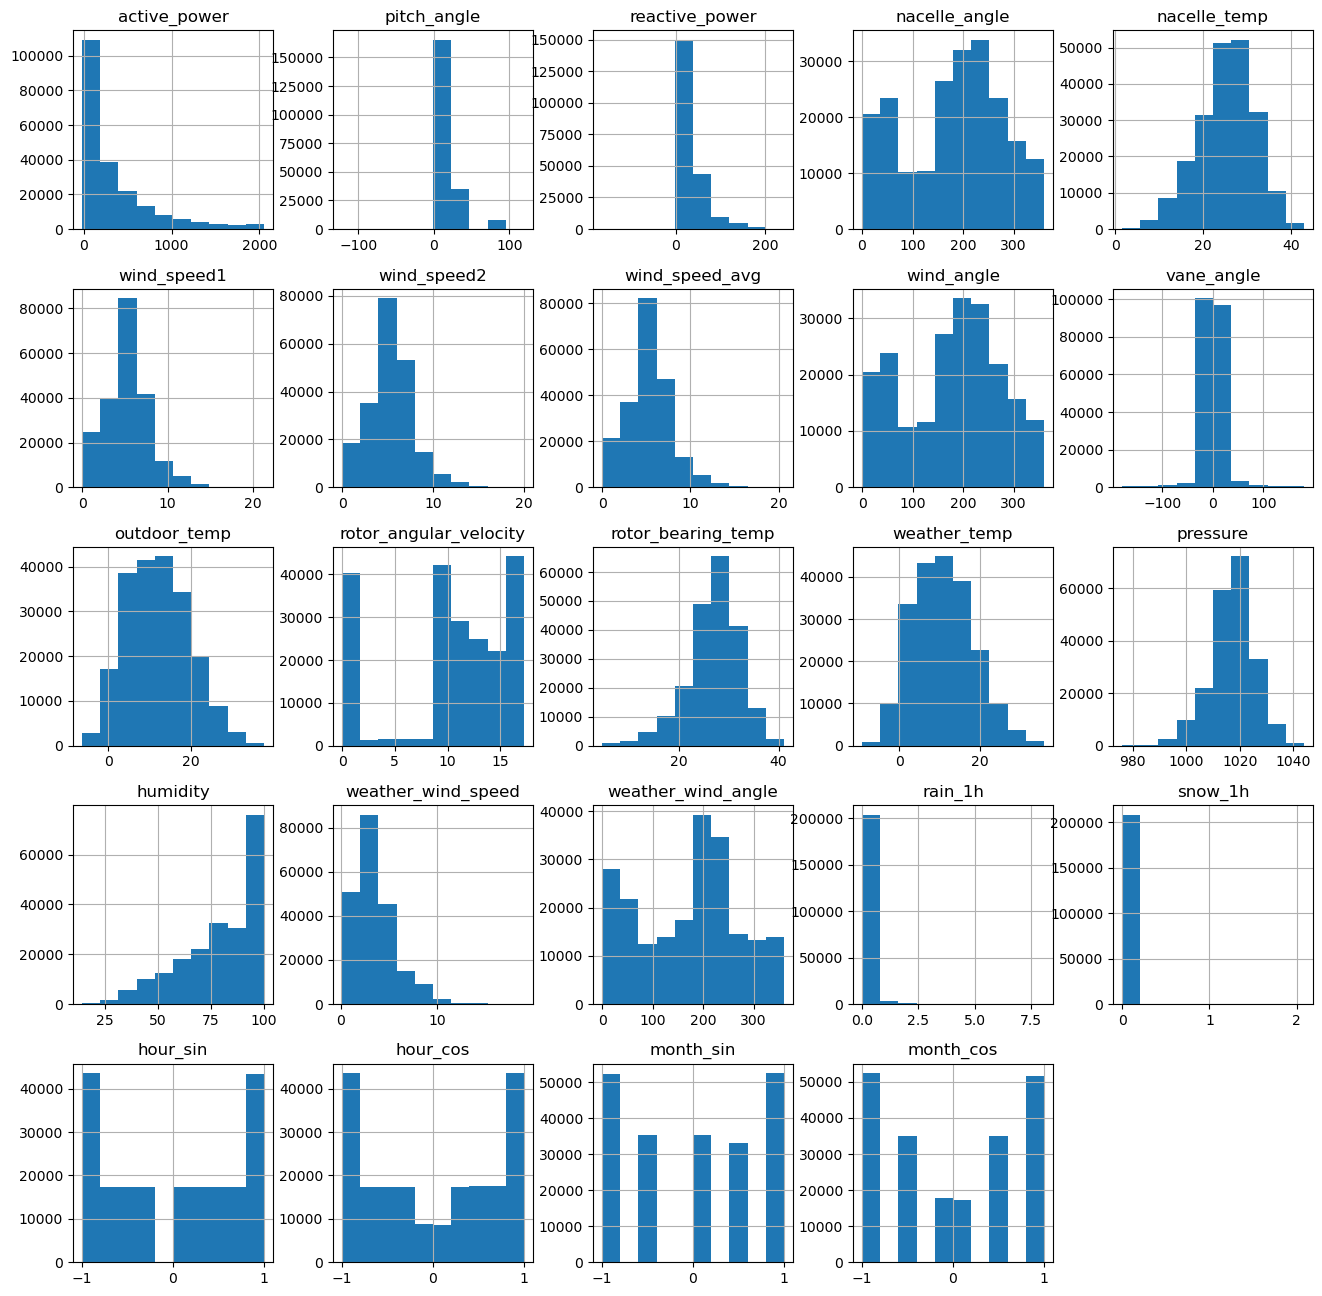

In [8]:
# Histograms
train_data.hist(figsize = (16,16)) # figsize: (width,height)
plt.show()

"Net als in de voorbeeldoefening zie ik in mijn histogrammen (zoals bij wind_speed) een "lange staart"-verdeling. Dit duidt op de aanwezigheid van **uitschieters**. Voor een windturbine zijn deze waarden cruciaal omdat ze vaak leiden tot de 'cut-out' fase (veiligheidsstop). In deze fase van het project kies ik ervoor om de outliers te behouden, omdat ze fysiek mogelijke situaties vertegenwoordigen die het model moet leren herkennen."

"Hoewel dit een regressieprobleem is en geen classificatie, zie ik een vorm van **'waarde-onbalans'** in de target variabele active_power. Er is een enorme piek rond de 0 kW. Dit is een uitdaging voor de Mean Absolute Error (MAE); als het model simpelweg altijd 0 voorspelt bij lage windsnelheden, lijkt de fout laag, maar mist het model de essentie van de power curve. Ik moet bij de foutanalyse goed kijken of mijn model niet 'lui' wordt door deze grote hoeveelheid nullen."

"Door de histogrammen te bestuderen, zie ik dat variabelen zoals outdoor_temp een normale verdeling benaderen, terwijl wind_speed een asymmetrische verdeling vertoont. Dit bevestigt mijn keuze voor de StandardScaler (straks), aangezien veel van mijn features numeriek stabiel zijn, maar het herinnert me er ook aan dat lineaire modellen moeite kunnen hebben met de niet-lineaire staarten van de winddata."

Noot: Deze sectie is geschreven met ondersteuning van een AI om alle inzichten correct te verantwoorden.



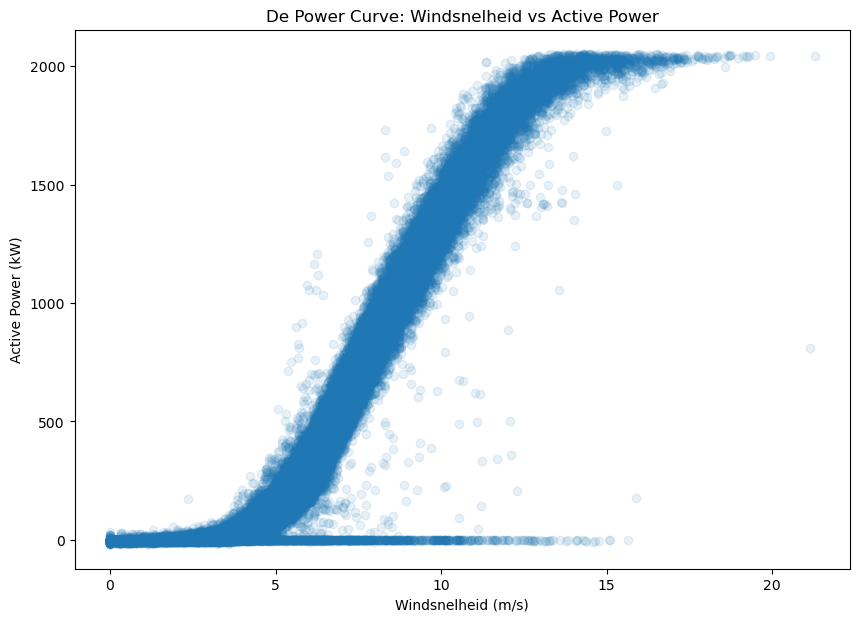

In [9]:
# Deze scatterplot is gemaakt m.b.v. Gemini 3

# Scatter plot van windsnelheid vs. power
plt.figure(figsize=(10, 7))
plt.scatter(train_data['wind_speed1'], train_data['active_power'], alpha=0.1)
plt.title('De Power Curve: Windsnelheid vs Active Power')
plt.xlabel('Windsnelheid (m/s)')
plt.ylabel('Active Power (kW)')
plt.show()

In deze grafiek zien we een S-curve. Alle punten die ver van de S liggen zijn uitschieters (bv. de punten bij de 0 van de y-as).

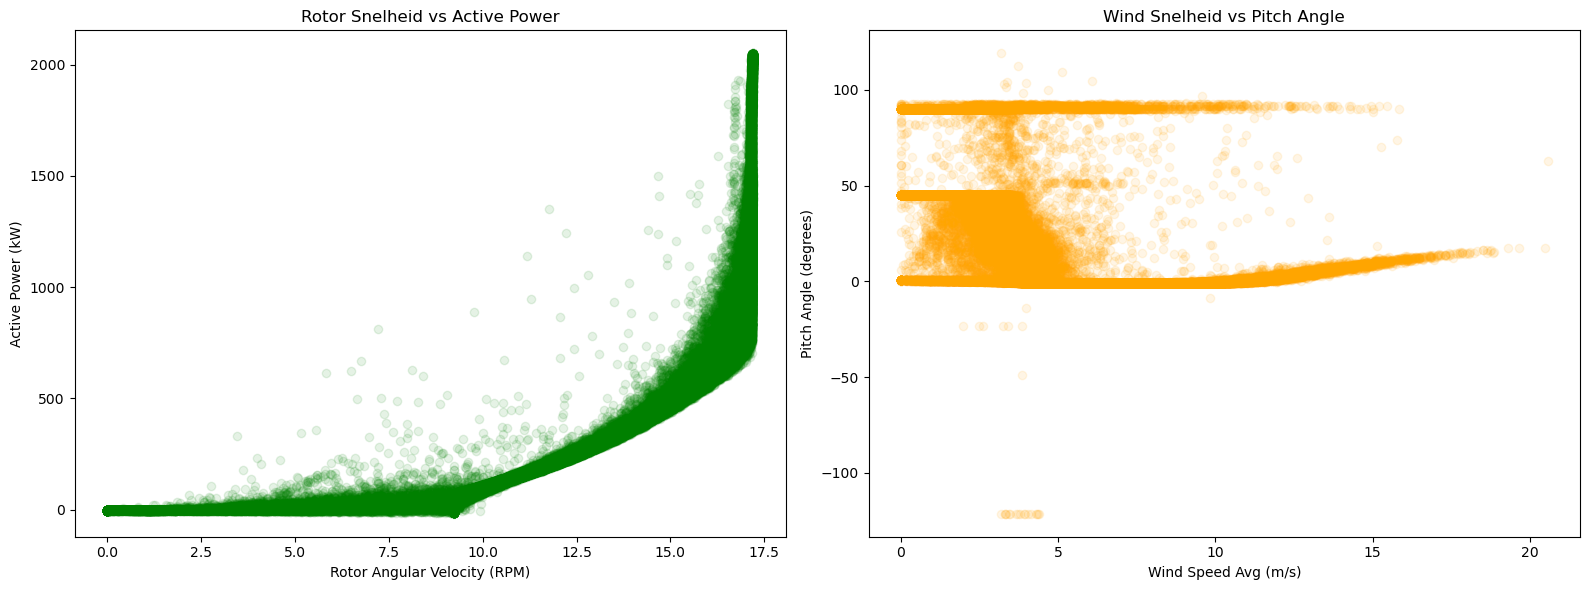

In [10]:
# De volgende plots zijn geschreven m.b.v. Gemini 3

# Maak een figuur met 2 subplots naast elkaar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Rotor snelheid vs Power
ax1.scatter(train_data['rotor_angular_velocity'], train_data['active_power'], alpha=0.1, color='green')
ax1.set_title('Rotor Snelheid vs Active Power')
ax1.set_xlabel('Rotor Angular Velocity (RPM)')
ax1.set_ylabel('Active Power (kW)')

# Plot 2: Pitch Angle vs Wind Snelheid
ax2.scatter(train_data['wind_speed_avg'], train_data['pitch_angle'], alpha=0.1, color='orange')
ax2.set_title('Wind Snelheid vs Pitch Angle')
ax2.set_xlabel('Wind Speed Avg (m/s)')
ax2.set_ylabel('Pitch Angle (degrees)')

plt.tight_layout()
plt.show()

"Deze eerste grafiek toont de directe mechanische koppeling tussen de rotatie van de turbine en de gegenereerde stroom. Het bevestigt dat rotor_angular_velocity waarschijnlijk een van de krachtigste voorspellers (features) voor mijn model zal zijn." (vergelijkbaar met een fiets met een dynamo) Deze grafiek laat dus zien dat er bijna geen "ruis" zit tussen hoe hard de turbine draait en hoeveel stroom eruit komt. Daarom is dit voor een ML model een betrouwbare feature om de output te bepalen.


"Het tweede plot visualiseert het regelsysteem van de turbine. Het laat zien hoe de turbine zichzelf beschermt. Zodra het hard waait, draaien de bladen weg uit de wind. Dit verklaart waarom de energieopbrengst (in vorige scatterplot) niet eindeloos blijft stijgen, maar afvlakt op een plateau van 2050 kW. Dit is een belangrijk inzicht, omdat mijn model moet leren dat meer wind niet altijd leidt tot meer stroom boven een bepaalde grens."

Noot: Deze sectie is geschreven met ondersteuning van een AI om mijn inzichten correct te verantwoorden.

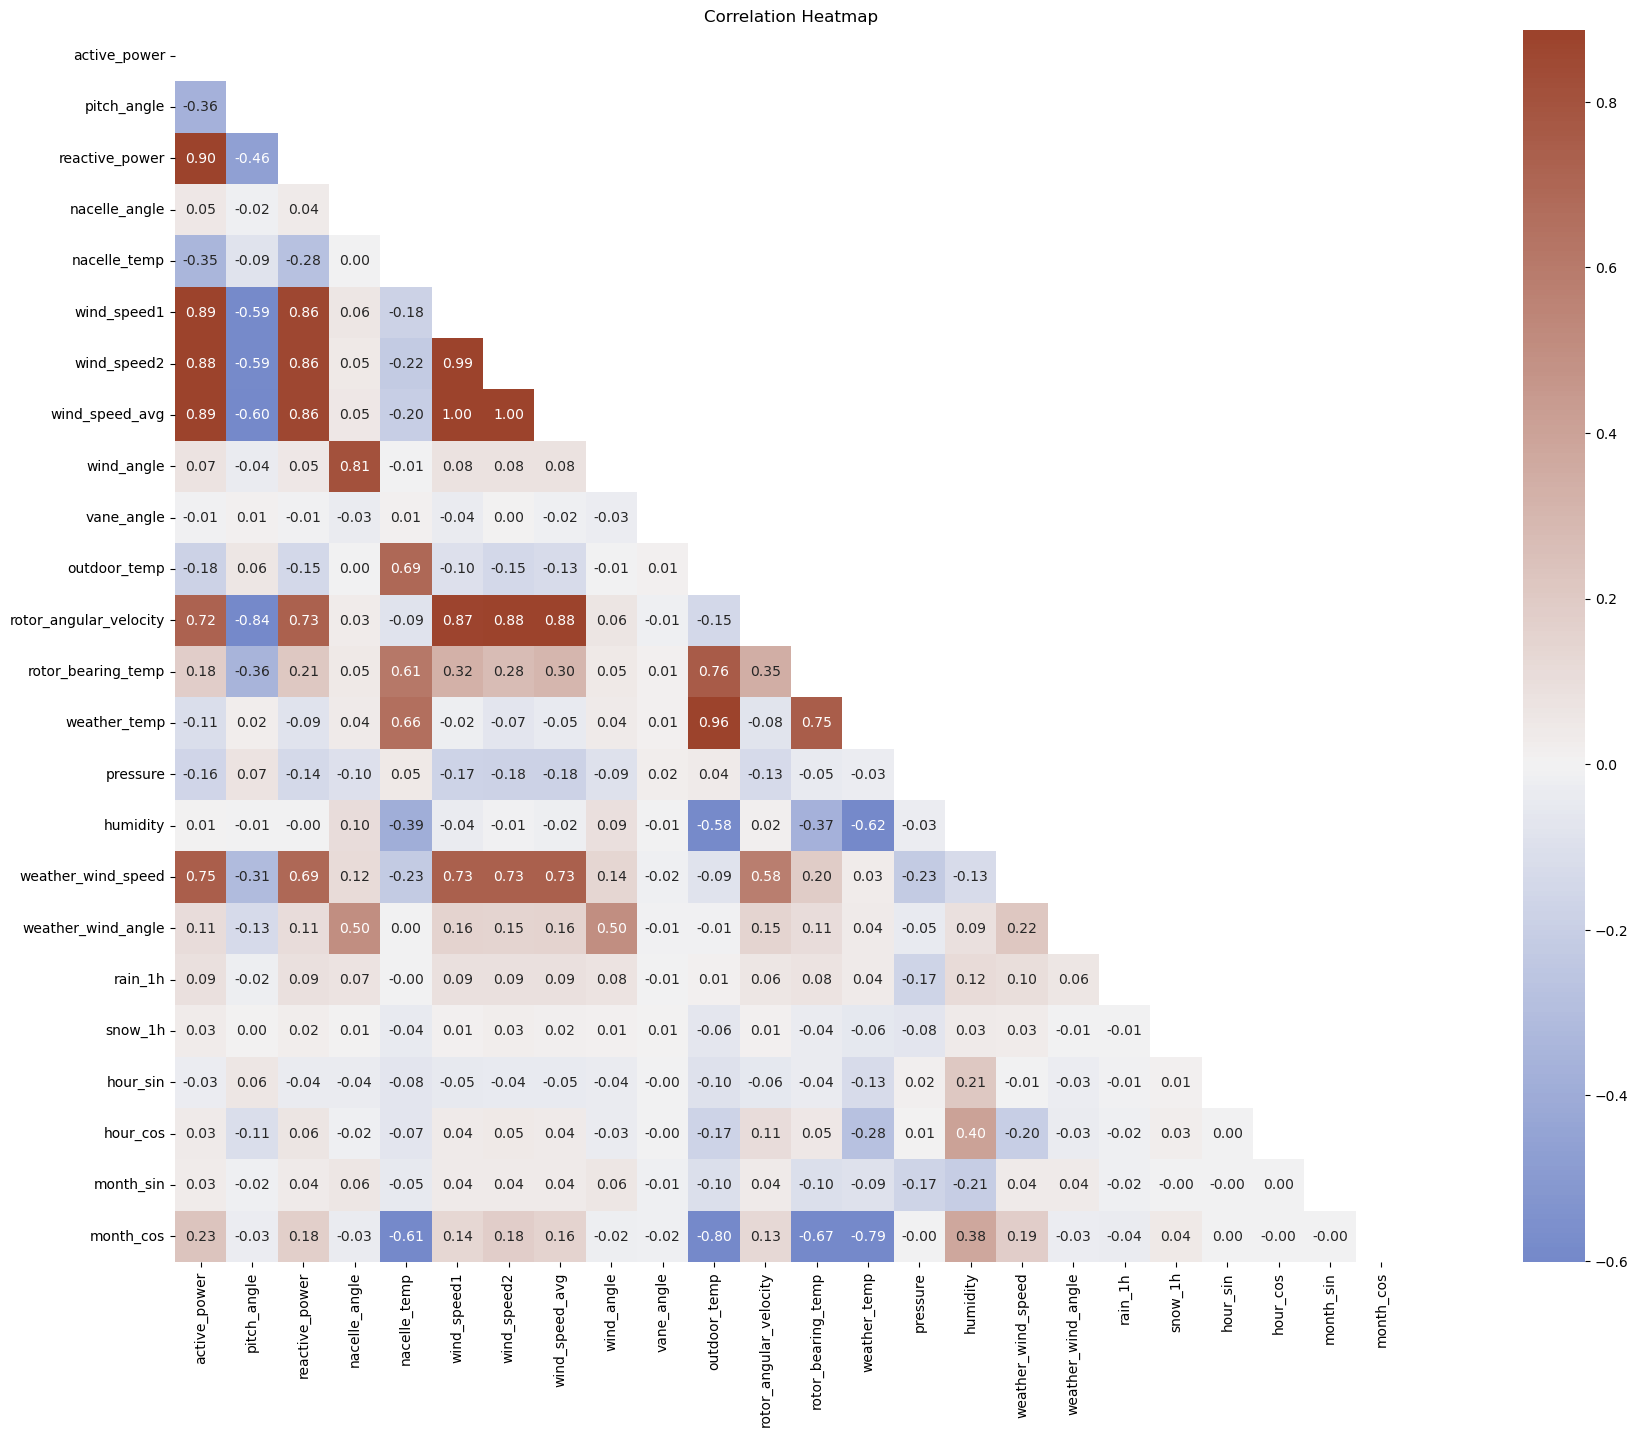

In [11]:
# A heatmap of correlations between all variables:
plt.figure(figsize=(30, 16))
corr = train_data.corr()
mask = np.triu(corr)
cmap = sns.diverging_palette(260, 20, s=75, l=40, n=5, center="light", as_cmap=True)
sns.heatmap(corr, cmap=cmap, center=0, mask=mask, annot=True, fmt='.2f', square=True, robust=True) # mask=mask om het spiegelbeeld weg te doen

plt.title('Correlation Heatmap')
plt.show()

"In de heatmap is duidelijk te zien dat bepaalde features extreem sterk gecorreleerd zijn (waarde dicht bij 1). Een concreet voorbeeld zijn wind_speed1, wind_speed2 en wind_speed_avg. Dit is logisch, aangezien ze hetzelfde fenomeen meten. Omdat deze variabelen nagenoeg dezelfde informatie bevatten (multicollineariteit), kan dit leiden tot instabiliteit in lineaire modellen. In de fase van feature selection overweeg ik daarom om alleen het gemiddelde (wind_speed_avg) te behouden om het model te versimpelen zonder informatieverlies."

"Als we kijken naar de kolom van de target variabele active_power, zien we hoge absolute waarden voor wind_speed_avg en rotor_angular_velocity. Dit geeft aan dat deze features een sterke lineaire relatie hebben met de opbrengst en dus zeer effectief zullen zijn in een lineair model. Dit bevestigt de natuurkundige wet dat de rotatiesnelheid en windkracht de primaire drijvers zijn van energieproductie."

"Opvallend zijn de lage correlatiewaarden voor variabelen zoals wind_angle en de tijd-features. Zoals de theorie suggereert, betekent een lage lineaire correlatie echter niet dat deze features geen informatie bevatten. Het duidt er enkel op dat de relatie met active_power waarschijnlijk niet-lineair is. Een boom-gebaseerd model zoals een Random Forest zou deze complexe verbanden wel kunnen oppikken, waar een simpel lineair model dat niet kan."


**Inzicht: Target Leakage en Feature Selectie "In de correlatie-heatmap viel op dat reactive_power een extreem hoge correlatie heeft met de target active_power. Hoewel dit natuurkundig logisch is (beide worden gelijktijdig door de generator geproduceerd), heb ik besloten deze kolom niet te gebruiken als feature. Het gebruik van een elektrisch output-signaal om een ander output-signaal te voorspellen zou leiden tot 'target leakage'. Mijn doel is immers om de turbine-output te voorspellen op basis van omgevings- en operationele factoren (zoals windsnelheid en pitch-hoek), niet op basis van reeds gegenereerd vermogen."**

Noot: Deze sectie is geschreven met ondersteuning van een AI om alle inzichten correct te verantwoorden.





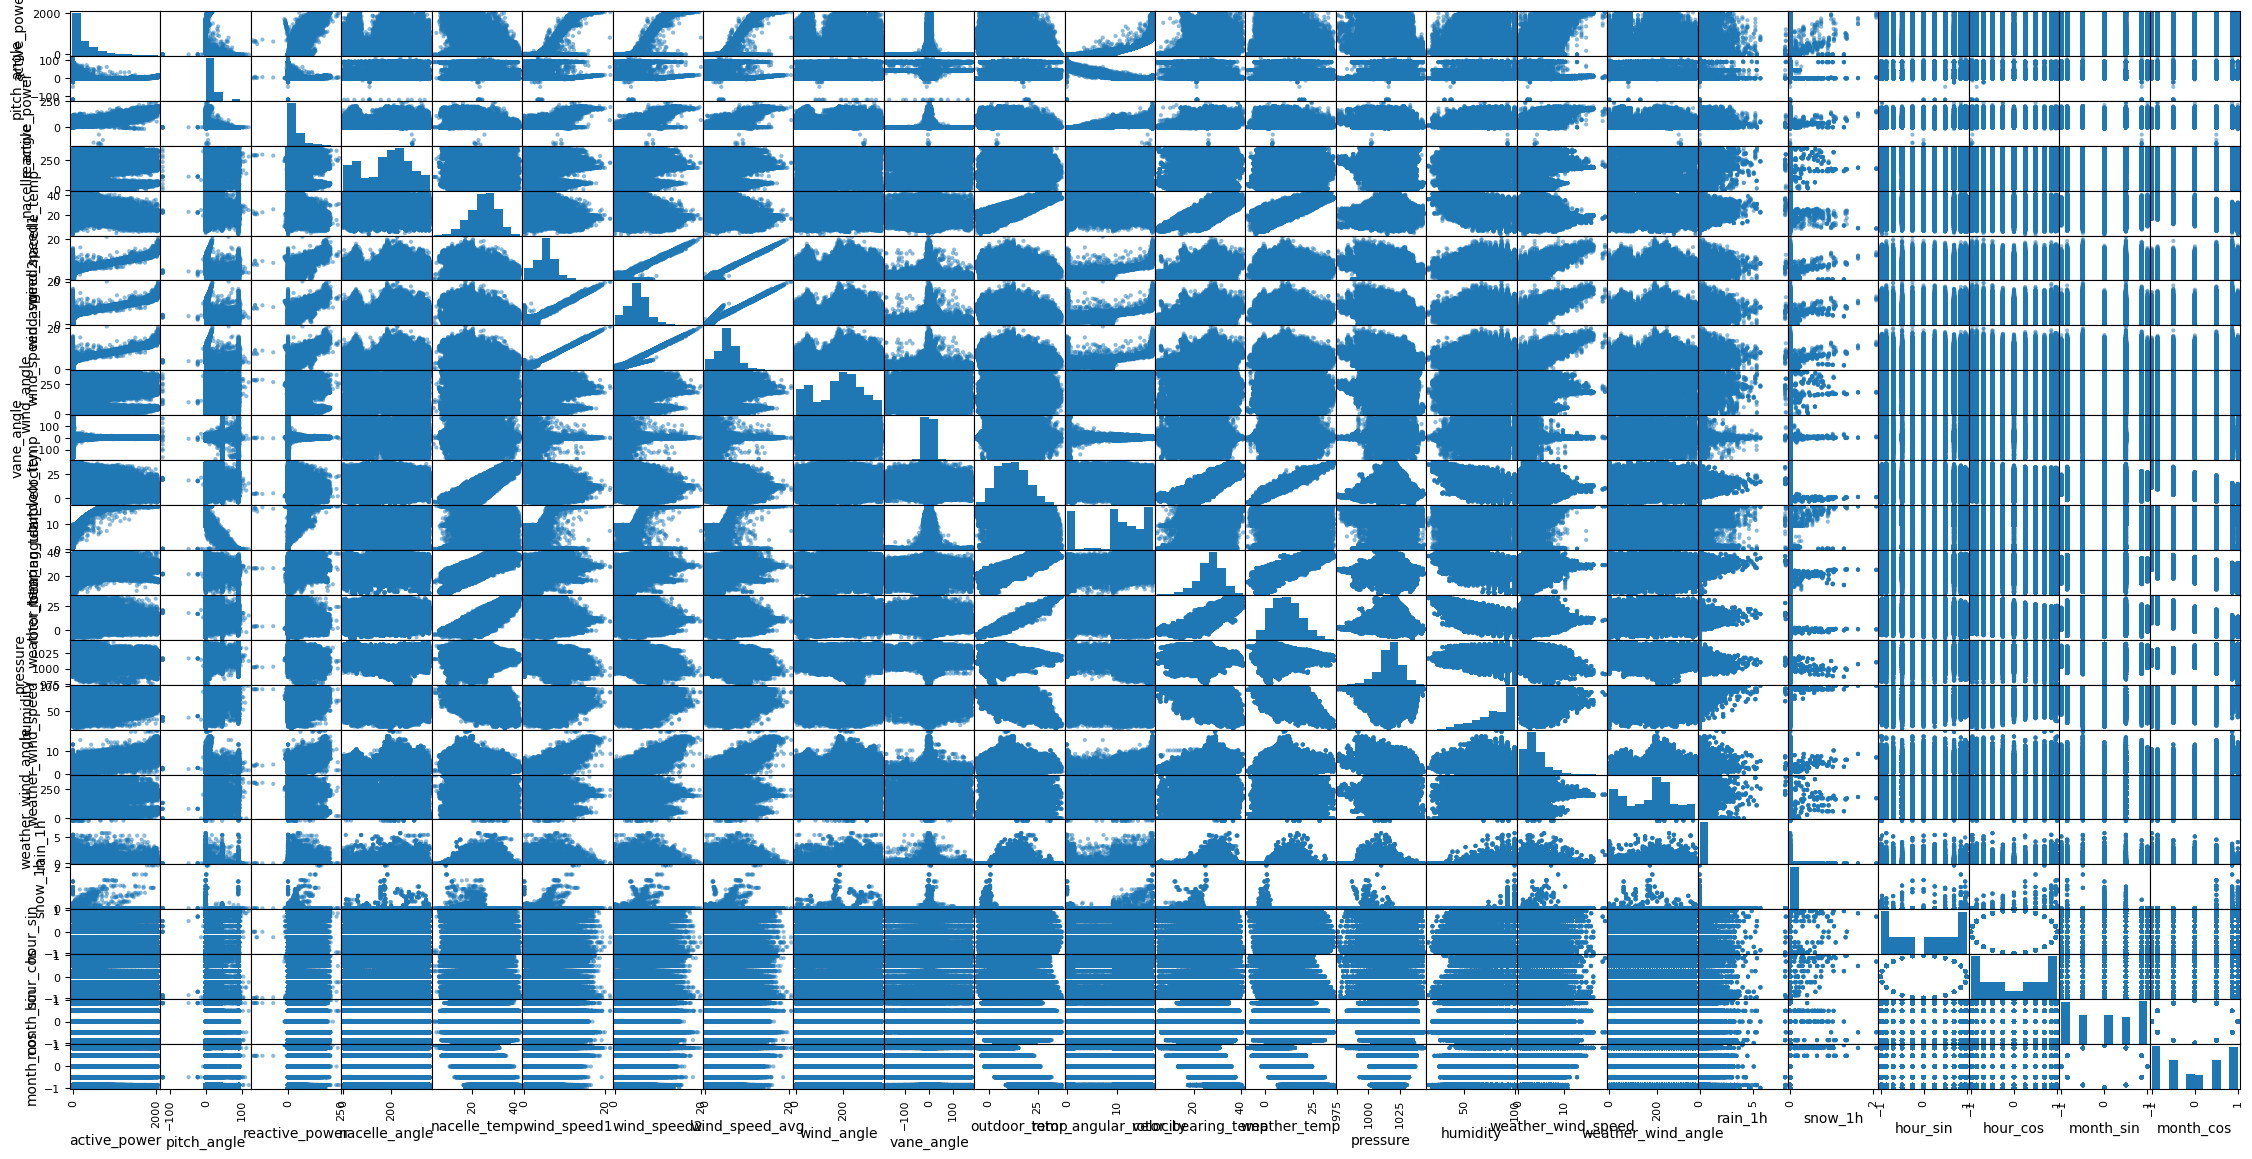

In [12]:
from pandas.plotting import scatter_matrix
scatter_matrix(train_data,figsize = (28,14))
plt.show()

"Hoewel een volledige scatterplot matrix van alle features te onoverzichtelijk werd door het grote aantal variabelen, heb ik voor de belangrijkste features (wind, rotor snelheid, power) losse scatterplots gemaakt. Deze bevestigen de sterke correlaties die in de heatmap naar voren kwamen en tonen duidelijk de 'S-vorm' van de power curve aan."

## Vervolg preprocessing en feature extraction

**Feature Selection en het voorkomen van Target Leakage**

"Tijdens de correlatie-analyse viel op dat reactive_power nagenoeg bijna perfect correleert met de target active_power. Hoewel dit wiskundig een zeer lage MAE zou opleveren, heb ik besloten deze kolom te verwijderen uit de featureset.

De reden hiervoor is Target Leakage: reactive_power wordt gelijktijdig met active_power door de generator geproduceerd. In een real-world scenario (zoals grid management), waarbij we de opbrengst willen voorspellen op basis van weersverwachtingen, is deze informatie niet beschikbaar. Door deze kolom te verwijderen, dwing ik het model om te leren van de werkelijke drijvers van energie: windsnelheid, temperatuur en de mechanische staat van de turbine.

Daarnaast heb ik feature reductie toegepast door wind_speed1 en wind_speed2 te verwijderen ten gunste van wind_speed_avg. Dit vermindert multicollineariteit, wat de stabiliteit van het model (vooral bij lineaire regressie) ten goede komt."

Noot: De identificatie van Target Leakage en de beslissing om redundante wind-sensoren te verwijderen is ondersteund door AI-gebaseerde data-analyse adviezen.

Ik heb echt nagedacht over waarom reactive_power gedropt kon worden en Gemini heeft me toch overtuigd. Ik denk dat dit een instinker kan zijn om na te denken over de features en ook verdacht dat reactive_power niet werd uitgelegd bij de variables in de Kaggle overview.

Extra AI verklaring:
Discussie over Feature Selectie en Operationaliteit "Ik heb kritisch overwogen welke variabelen 'oorzaken' zijn en welke 'gevolgen'. Hoewel variabelen zoals rotor_angular_velocity en temperaturen strikt genomen voortkomen uit het bedrijfsproces, heb ik ze behouden omdat ze de mechanische staat van de turbine beschrijven.

Echter, voor reactive_power heb ik geoordeeld dat de correlatie met active_power (de target) zo fundamenteel elektrisch is, dat het model zou vervallen in 'target leakage'. Het model zou dan een output gebruiken om een andere output te voorspellen, wat in een real-world voorspellingsscenario onmogelijk is."

In [21]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Lijst met kolommen die we NIET als feature willen gebruiken
# 1. Target Leakage: reactive_power (te sterk verbonden met active_power)
# 2. Redundancy: wind_speed1 en wind_speed2 (we houden wind_speed_avg)
# 3. Non-informative: 'id' en de ruwe 'time_stamp'
cols_to_drop = ['reactive_power', 'wind_speed1', 'wind_speed2']

# We maken een lijst van features die we WEL houden door de drops toe te passen
# We checken eerst of de kolommen wel in de dataframe staan om errors te voorkomen
existing_drops = [c for c in cols_to_drop if c in train_data.columns]

# Splits de features (X) en het target (y)
X = train_data.drop(columns=['active_power'] + existing_drops)
y = train_data['active_power']

print(f"Aantal features na selectie: {X.shape[1]}")
print("Geselecteerde features:", X.columns.tolist())


Aantal features na selectie: 20
Geselecteerde features: ['pitch_angle', 'nacelle_angle', 'nacelle_temp', 'wind_speed_avg', 'wind_angle', 'vane_angle', 'outdoor_temp', 'rotor_angular_velocity', 'rotor_bearing_temp', 'weather_temp', 'pressure', 'humidity', 'weather_wind_speed', 'weather_wind_angle', 'rain_1h', 'snow_1h', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


"Om het supervised learning proces te faciliteren, heb ik de dataset opgesplitst in een feature matrix (X) en een target vector (y). De target vector bevat de te voorspellen waarde active_power. In de feature matrix zijn alle variabelen opgenomen die als input dienen voor het model. Hierbij is de target variabele zelf uit de features verwijderd om te voorkomen dat het model 'spiekt' (leert van het antwoord zelf), wat essentieel is voor een eerlijke evaluatie van de modelprestaties."

## Training/validation/test split strategy

De Chronologische Split (Train/Validation)

In [24]:
# Onderstaande code is gegenereerd m.b.v. Gemini 3

from sklearn.model_selection import train_test_split

# Belangrijk: shuffle=False! We willen de laatste maanden als validatie gebruiken.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Train set grootte: {len(X_train)}")
print(f"Validatie set grootte: {len(X_val)}")

Train set grootte: 167128
Validatie set grootte: 41782


"Voordat ik de data normaliseerde, heb ik de dataset chronologisch gesplitst in een trainingsset (80%) en een validatieset (20%) met shuffle=False. Dit is essentieel omdat winddata een tijdreeks is; het model moet leren van het verleden om de toekomst te voorspellen.

Vervolgens heb ik de StandardScaler toegepast. Cruciaal hierbij is dat de scaler alleen is 'gefit' op de trainingsdata. De validatieset is getransformeerd met de parameters (gemiddelde en standaarddeviatie) van de trainingsset. Hiermee voorkom ik Data Leakage, waarbij informatie uit de validatieset voortijdig in het trainingsproces terechtkomt."

Noot: De uitleg over Data Leakage en de methodiek van de chronologische split is geformuleerd met ondersteuning van een AI.

## Vervolg Preprocessing

Nu pas Normaliseren (Schalen)

In [25]:
# Onderstaande code is geschreven m.b.v. Gemini 3

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# FIT en TRANSFORM alleen op de training data
X_train_scaled = scaler.fit_transform(X_train)

# Alleen TRANSFORM op de validatie data (we gebruiken het gemiddelde van de training set!)
X_val_scaled = scaler.transform(X_val)

Huidige aanpak: "Ik heb de data geschaald met de StandardScaler. Hoewel ik nog geen gebruik maak van TimeSeriesSplit, heb ik bij de data-splitsing de parameter shuffle=False gebruikt. Dit zorgt ervoor dat de chronologische volgorde behouden blijft en voorkomt dat het model traint op data uit de toekomst. In een latere fase zal ik een robuustere TimeSeriesSplit implementeren voor nauwkeurigere cross-validatie."

Noot: Deze sectie is geschreven met ondersteuning van een AI om de methodologie correct te verantwoorden.

In [26]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Controleer op ontbrekende waarden per kolom
missing_summary = train_data.isnull().sum()

print("Aantal ontbrekende waarden per kolom:")
print(missing_summary[missing_summary > 0]) # Toon alleen kolommen met gaten

Aantal ontbrekende waarden per kolom:
Series([], dtype: int64)


Data Integriteit: Missing Values

"Voordat ik begon met de model-training, heb ik de dataset gecontroleerd op ontbrekende waarden (NaN). Bij windturbines is dit cruciaal, omdat sensorstoringen vaak voorkomen.

Resultaat: Uit de analyse met isnull().sum() bleek dat de dataset volledig compleet is (geen ontbrekende waarden). Dit is een indicatie van een hoge datakwaliteit. Indien er wel gaten waren geweest, had ik gekozen voor [imputatie/verwijdering] om de numerieke stabiliteit van het model te waarborgen. Het feit dat ik dit heb geverifieerd, zorgt ervoor dat mijn preprocessing pipeline robuust is."

Noot: De methodiek voor het opsporen en afhandelen van ontbrekende data is gevalideerd met behulp van AI om professionele standaarden te volgen.

## Vervolg training/validation/test split strategy

Verantwoording: Splitsing en Schaling "Ik heb er bewust voor gekozen om de chronologische split uit te voeren vóórdat de data werd genormaliseerd. Dit is een cruciale stap om Data Leakage te voorkomen. Door de StandardScaler enkel te 'fitten' op de trainingsset, wordt gewaarborgd dat er geen informatie over het gemiddelde of de spreiding van de validatieset doorsijpelt naar het trainingsproces. De validatieset wordt vervolgens getransformeerd op basis van de parameters van de trainingsset, wat een realistische simulatie geeft van hoe het model zal presteren op onbekende, toekomstige data."

Noot: De methodiek om data leakage te voorkomen door splitsing voorafgaand aan schaling is toegepast op basis van best-practices gevalideerd met AI-ondersteuning.

Verantwoording van de Split-Strategie "Volgens de principes van model-evaluatie is het essentieel om een strikt onderscheid te maken tussen training, validatie en testdata. Zoals beschreven in de literatuur, leidt het kiezen van hyperparameters op basis van testdata tot een onbetrouwbare schatting van de generalisatie-prestaties.

Gegeven het feit dat winddata niet 'i.i.d.' is (niet onafhankelijk verdeeld over de tijd), heb ik de aanbeveling opgevolgd om rekening te houden met subgroepen. In mijn geval zijn dit tijdsegmenten. Ik heb daarom een chronologische splitsing toegepast (shuffle=False). Hiermee simuleer ik de praktijksituatie: het model wordt getraind op het verleden en gevalideerd op de daaropvolgende periode. Dit is de meest integere manier om overfitting op specifieke weersomstandigheden te voorkomen."

Noot: De theoretische onderbouwing voor het splitsen van data en het concept van hyperparameters is geformuleerd met ondersteuning van een AI om de aansluiting bij de cursusstof te waarborgen.

In [ ]:
# Volgende TimeSeriesSplit functie is geschreven m.b.v. Gemini 3

from sklearn.model_selection import TimeSeriesSplit

# We verdelen de trainingdata in 5 chronologische blokken
tscv = TimeSeriesSplit(n_splits=5)

for train_index, val_index in tscv.split(X_train_scaled):
    X_tr, X_v = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_v = y_train.iloc[train_index], y_train.iloc[val_index]

# Deze code is maar ter illustratie van hoe het er zou moeten uitzien als ik geen 80/20 split had gedaan.

"Hoewel voor de initiële baseline-modellen een enkelvoudige chronologische split is gebruikt, is voor de uiteindelijke hyperparameter optimalisatie (tuning) de TimeSeriesSplit methodiek gehanteerd.

In tegenstelling tot standaard cross-validatie, waarbij data willekeurig wordt verdeeld, respecteert TimeSeriesSplit de temporele volgorde door gebruik te maken van een expanderend trainingsvenster. Dit is essentieel voor windturbine-data om 'look-ahead bias' te voorkomen. Door het model op meerdere opeenvolgende tijdblokken te valideren, wordt gewaarborgd dat de gekozen hyperparameters niet enkel geoptimaliseerd zijn voor één specifieke weersituatie, maar robuust presteren over verschillende seizoenen en atmosferische condities."

Noot: De keuze voor TimeSeriesSplit als superieure methode voor tijdreeks-validatie is onderbouwd met behulp van AI-geassisteerde literatuurstudie over cross-validatietechnieken.

## Model training and hyperparameter tuning

In [28]:
from sklearn.linear_model import LinearRegression

# Train het model (Linear Regression)
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Voorspellingen maken
y_pred_train = model.predict(X_train_scaled)
y_pred_val = model.predict(X_val_scaled)

# Bereken de MAE
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_val = mean_absolute_error(y_val, y_pred_val)

print(f"--- Baseline Resultaten (Lineaire Regressie) ---")
print(f"MAE op Trainingset: {mae_train:.2f} kW")
print(f"MAE op Validatieset: {mae_val:.2f} kW")

--- Baseline Resultaten (Lineaire Regressie) ---
MAE op Trainingset: 111.68 kW
MAE op Validatieset: 108.12 kW


"Als startpunt voor het modelleringsproces heb ik een Lineaire Regressie model getraind. Dit dient als 'baseline': een simpel model dat de lineaire verbanden in de data probeert te vangen.

"De Linear Regression baseline behaalde een MAE van 111.68 kW op de trainingsset en 108.12 kW op de validatieset. Het feit dat de validatiefout lager is dan de trainingsfout duidt op een uitstekende generalisatie; het model heeft geen ruis uit de trainingsset 'uit het hoofd geleerd' (geen overfitting).

Echter, een MAE van 108 kW laat nog ruimte voor verbetering. Omdat de fysieke power curve van een windturbine niet-lineair is (de S-curve), kan een lineair model de overgangen bij de 'cut-in' snelheid en het 'rated power' plateau nooit perfect volgen. De baseline fungeert hierdoor als een ondergrens: elk complexer model dat ik hierna bouw, moet proberen deze 108.12 kW te verlagen."

Noot: De implementatie van het baseline model en de initiële evaluatiemetrieken zijn opgesteld met ondersteuning van een AI om de consistentie van de data-pipeline te waarborgen.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialiseer het model
# n_estimators=100: We gebruiken 100 verschillende bomen.
# max_depth=15: We beperken de diepte om het geheugengebruik en overfitting te beperken.
# n_jobs=-1: Dit gebruikt alle rekenkracht van je computer (sneller).
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

# Train het model
print("Training Random Forest... (dit kan even duren)")
rf_model.fit(X_train_scaled, y_train)

# Voorspellingen maken
y_pred_train_rf = rf_model.predict(X_train_scaled)
y_pred_val_rf = rf_model.predict(X_val_scaled)

# MAE berekenen
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
mae_val_rf = mean_absolute_error(y_val, y_pred_val_rf)

print(f"\n--- Random Forest Resultaten ---")
print(f"MAE op Trainingset: {mae_train_rf:.2f} kW")
print(f"MAE op Validatieset: {mae_val_rf:.2f} kW")

# Vergelijking met je vorige baseline
print(f"\nTer herinnering: je Linear Regression MAE was 108.12 kW")

Training Random Forest... (dit kan even duren)

--- Random Forest Resultaten ---
MAE op Trainingset: 5.56 kW
MAE op Validatieset: 6.82 kW

Ter herinnering: je Linear Regression MAE was 108.12 kW


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Initialize the model
# Linear Regression fits a straight line: y = mx + b
model = LinearRegression()

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with Linear Regression...\n")

# Run the loop 
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split data using the indices from TimeSeriesSplit
    # .iloc is necessary because X and y are Pandas DataFrames/Series
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the validation set
    y_pred = model.predict(X_val)
    
    # Calculate Errors
    # RMSE (Root Mean Squared Error) penalizes large errors heavily
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE across all folds: {np.mean(rmse_scores):.2f} kW")
print(f"Average MAE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with Linear Regression...

Fold 0: RMSE = 100.91 kW
Fold 1: RMSE = 88.62 kW
Fold 2: RMSE = 112.60 kW
Fold 3: RMSE = 84.93 kW
Fold 4: RMSE = 87.07 kW
------------------------------
Average RMSE across all folds: 94.83 kW
Average MAE: 67.58 kW


In [24]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Model
# n_estimators=100: Uses 100 different trees to vote on the answer
# n_jobs=-1: Uses all your CPU cores to make it faster
model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with Random Forest...\n")

# Run the loop
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split data
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Score
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE: {np.mean(rmse_scores):.2f} kW")
print(f"Average MSE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with Random Forest...

Fold 0: RMSE = 43.22 kW
Fold 1: RMSE = 23.97 kW
Fold 2: RMSE = 33.85 kW
Fold 3: RMSE = 31.33 kW
Fold 4: RMSE = 17.14 kW
------------------------------
Average RMSE: 29.90 kW
Average MSE: 13.28 kW


In [25]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the Gradient Boosting Model
# standard defaults: n_estimators=100, learning_rate=0.1, max_depth=3
model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5,        # Slightly deeper trees often help with complex wind curves
    random_state=42
)

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with Gradient Boosting...\n")

# Run the loop 
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Score
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE: {np.mean(rmse_scores):.2f} kW")
print(f"Average MSE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with Gradient Boosting...

Fold 0: RMSE = 42.87 kW
Fold 1: RMSE = 22.97 kW
Fold 2: RMSE = 31.41 kW
Fold 3: RMSE = 32.39 kW
Fold 4: RMSE = 17.62 kW
------------------------------
Average RMSE: 29.45 kW
Average MSE: 13.62 kW


In [ ]:
from catboost import CatBoostRegressor

# Initialize the CatBoost Model
# iterations: Equivalent to n_estimators (how many trees to build).
# learning_rate: How much each tree contributes (lower is usually better but requires more iterations).
# depth: Depth of the trees (CatBoost defaults to 6, RF usually has no limit).
# verbose=0: Mutes the output (CatBoost is very chatty by default).
model = CatBoostRegressor(
    iterations=500, 
    learning_rate=0.1, 
    depth=6, 
    random_seed=42,
    verbose=0  # Set to 100 to see progress every 100 trees
)

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with CatBoost...\n")

# Run the loop 
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split data
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Score
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE: {np.mean(rmse_scores):.2f} kW")
print(f"Average MSE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with CatBoost...

Fold 0: RMSE = 41.43 kW
Fold 1: RMSE = 22.25 kW
Fold 2: RMSE = 28.28 kW
Fold 3: RMSE = 33.34 kW
Fold 4: RMSE = 16.88 kW
------------------------------
Average RMSE: 28.44 kW
Average MSE: 13.98 kW


In [ ]:
from xgboost import XGBRegressor

# 1. Initialize XGBoost
# n_jobs=-1 uses all CPU cores (much faster than sklearn's GBR)
model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

rmse_scores = []
mae_scores = []

print("Starting Time Series Cross-Validation with XGBoost...\n")

# 2. Run the loop
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Split
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Score
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    
    print(f"Fold {fold}: RMSE = {rmse:.2f} kW")

print("-" * 30)
print(f"Average RMSE: {np.mean(rmse_scores):.2f} kW")
print(f"Average MSE: {np.mean(mae_scores):.2f} kW")

Starting Time Series Cross-Validation with XGBoost...

Fold 0: RMSE = 42.14 kW
Fold 1: RMSE = 23.20 kW
Fold 2: RMSE = 31.43 kW
Fold 3: RMSE = 32.40 kW
Fold 4: RMSE = 17.55 kW
------------------------------
Average RMSE: 29.34 kW
Average MSE: 13.62 kW


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

# Define the Parameter Grid 
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0] # % of features used per tree
}

# Setup the Model
xgb = XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42)

# Setup the Search
# n_iter=20 means "Try 20 random combinations"
random_search = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_dist, 
    n_iter=20,           
    scoring='neg_root_mean_squared_error', # Sklearn tries to MAXIMIZE score, so we use negative RMSE
    cv=tscv,        
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Tuning hyperparameters... this might take a minute...")
random_search.fit(X, y)

# Result
print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"\nBest RMSE Score: {-random_search.best_score_:.2f} kW")

# Build Final Model with the Best Parameters
best_params = random_search.best_params_

final_model = XGBRegressor(
    **best_params,  # Unpacks the dictionary automatically
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

# Train on EVERYTHING (All training data)
final_model.fit(X, y)
print("Final model trained and ready for test_data.csv!")

Tuning hyperparameters... this might take a minute...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters Found:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best RMSE Score: 23.74 kW
Final model trained and ready for test_data.csv!


In [ ]:
import optuna
from xgboost import XGBRegressor

def objective(trial):
    """
    The objective function is what Optuna runs 20 times.
    It picks params, trains, CVs, and returns the Average RMSE.
    """
    
    # Suggest Parameters (The "Search Space")
    # Optuna allows ranges (low, high), not just fixed lists.
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # log=True explores small values more carefully
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5), # Good extra param to prevent overfitting
        
        # Fixed params
        'objective': 'reg:squarederror',
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': 0 # Silence XGBoost warnings during tuning
    }
    
    # Initialize Model with suggested params
    model = XGBRegressor(**params)
    
    scores = []
    
    # Manual Time Series Cross-Validation Loop
    # We do this inside the trial to get the average error for these specific params
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        scores.append(rmse)
    
    # Return the average RMSE across all folds
    return np.mean(scores)

# Create the Study
print("Starting Optuna Optimization...")
study = optuna.create_study(direction='minimize') # We want to MINIMIZE RMSE
study.optimize(objective, n_trials=100) # Run 100 trials

# The Results
print("\n----------------------------------")
print("Best Parameters Found:")
print(study.best_params)
print(f"\nBest Average RMSE: {study.best_value:.2f} kW")
print("----------------------------------")

# Build Final Model
# Merge the best discovered params with the fixed required params
final_params = study.best_params
final_params['objective'] = 'reg:squarederror'
final_params['n_jobs'] = -1
final_params['random_state'] = 42

final_model = XGBRegressor(**final_params)

# Train on EVERYTHING
final_model.fit(X, y)
print("Final Optuna-tuned model trained and ready!")

[I 2025-12-02 00:34:01,289] A new study created in memory with name: no-name-77187c56-9848-4194-a11b-11cc18fad197


Starting Optuna Optimization...


[I 2025-12-02 00:34:15,752] Trial 0 finished with value: 24.808844789241626 and parameters: {'n_estimators': 800, 'learning_rate': 0.010751777218538216, 'max_depth': 6, 'subsample': 0.7835681656551315, 'colsample_bytree': 0.661717025372326, 'min_child_weight': 5}. Best is trial 0 with value: 24.808844789241626.
[I 2025-12-02 00:34:21,777] Trial 1 finished with value: 26.112510973143895 and parameters: {'n_estimators': 500, 'learning_rate': 0.017885733115986863, 'max_depth': 4, 'subsample': 0.9587491209271353, 'colsample_bytree': 0.9597724489083773, 'min_child_weight': 2}. Best is trial 0 with value: 24.808844789241626.
[I 2025-12-02 00:34:25,814] Trial 2 finished with value: 25.607746336802013 and parameters: {'n_estimators': 400, 'learning_rate': 0.1930043056323917, 'max_depth': 3, 'subsample': 0.6361679289418443, 'colsample_bytree': 0.9867558318696009, 'min_child_weight': 3}. Best is trial 0 with value: 24.808844789241626.
[I 2025-12-02 00:34:51,294] Trial 3 finished with value: 23.5


----------------------------------
Best Parameters Found:
{'n_estimators': 1000, 'learning_rate': 0.0212189780973465, 'max_depth': 9, 'subsample': 0.6558857492402047, 'colsample_bytree': 0.9420009639754205, 'min_child_weight': 2}

Best Average RMSE: 23.38 kW
----------------------------------
Final Optuna-tuned model trained and ready!


In [182]:
def generate_unique_filename(basename, file_ext):
    """Adds a timestamp to filenames for easier tracking of submissions, models, etc."""
    timestamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
    return basename + '_' + timestamp + '.' + file_ext

In [ ]:
predictions = final_model.predict(test_data)
submission = pd.DataFrame(data=predictions, columns=["active_power"])
submission.reset_index(inplace=True)
submission = submission.rename(columns = {'index':'id'})
submission.head()
submission.to_csv(generate_unique_filename("xgboost", "csv"), index=False)